In [5]:
%%capture
!wget https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip
!unzip data.zip

In [6]:

import numpy as np
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
from PIL import Image
import numpy as np

# Load an image
img = Image.open('/content/data/train/straight/1_Emily-Atack.jpg')

# Resize to target size
img = img.resize((200, 200))

# Convert to numpy array
x = np.array(img)
print(x.shape)

(200, 200, 3)


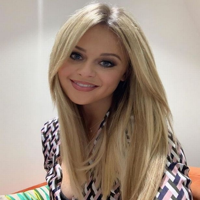

In [8]:
img

In [9]:
import torch
import torchvision.models as models
from torchvision import transforms
import numpy as np

# Preprocessing for MobileNetV2
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(200),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)

In [10]:
print(img_t.shape)
print(batch_t.shape)

torch.Size([3, 200, 200])
torch.Size([1, 3, 200, 200])


In [11]:
import os
from torch.utils.data import Dataset
from PIL import Image

class HairDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [12]:
from torchvision import transforms

input_size = 200

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Simple transforms - just resize and normalize
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [13]:
from torch.utils.data import DataLoader

train_dataset = HairDataset(
    data_dir='./data/train',
    transform=train_transforms
)

validation_dataset = HairDataset(
    data_dir='./data/test',
    transform=train_transforms
)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=20, shuffle=False)


In [15]:
import torch.nn as nn

class HairClassificationCNN(nn.Module):
    def __init__(self):
        super(HairClassificationCNN, self).__init__()
        # Convolutional layer: 3 input channels (RGB), 32 output channels, 3x3 kernel
        # Input shape: (3, 200, 200)
        self.conv_layer = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3),  # (32, 198, 198)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # (32, 99, 99)
        )

        # Compute flattened size: 32 * 99 * 99
        self.flatten_dim = 32 * 99 * 99

        self.fc_layers = nn.Sequential(
            nn.Linear(self.flatten_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            # nn.Sigmoid()   # binary classification activation
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc_layers(x)
        return x

In [16]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HairClassificationCNN().to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.002, momentum=0.8)
criterion = nn.BCEWithLogitsLoss()

In [17]:
print(model)

HairClassificationCNN(
  (conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=313632, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [18]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 20073473


In [19]:
from torchsummary import summary
summary(model, input_size=(3, 200, 200))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 198, 198]             896
              ReLU-2         [-1, 32, 198, 198]               0
         MaxPool2d-3           [-1, 32, 99, 99]               0
            Linear-4                   [-1, 64]      20,072,512
              ReLU-5                   [-1, 64]               0
            Linear-6                    [-1, 1]              65
Total params: 20,073,473
Trainable params: 20,073,473
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.46
Forward/backward pass size (MB): 21.54
Params size (MB): 76.57
Estimated Total Size (MB): 98.57
----------------------------------------------------------------


In [20]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(validation_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6538, Acc: 0.6380, Val Loss: 0.6299, Val Acc: 0.6716
Epoch 2/10, Loss: 0.5613, Acc: 0.6916, Val Loss: 0.6326, Val Acc: 0.6368
Epoch 3/10, Loss: 0.5271, Acc: 0.7216, Val Loss: 0.8837, Val Acc: 0.6119
Epoch 4/10, Loss: 0.6054, Acc: 0.6979, Val Loss: 0.6316, Val Acc: 0.6418
Epoch 5/10, Loss: 0.5363, Acc: 0.7341, Val Loss: 0.5861, Val Acc: 0.6667
Epoch 6/10, Loss: 0.4569, Acc: 0.7815, Val Loss: 0.5925, Val Acc: 0.6716
Epoch 7/10, Loss: 0.4221, Acc: 0.7953, Val Loss: 0.6614, Val Acc: 0.6368
Epoch 8/10, Loss: 0.3541, Acc: 0.8365, Val Loss: 1.0386, Val Acc: 0.5970
Epoch 9/10, Loss: 0.4078, Acc: 0.8202, Val Loss: 0.9616, Val Acc: 0.6070
Epoch 10/10, Loss: 0.4867, Acc: 0.7890, Val Loss: 0.6288, Val Acc: 0.6965


In [22]:
np.median(history['acc'])

np.float64(0.7578027465667916)

In [24]:
np.std(history['loss'])

np.float64(0.08856236310363251)

In [25]:
input_size = 200

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Simple transforms - just resize and normalize
train_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomRotation(50),
    transforms.RandomResizedCrop(200, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


train_dataset = HairDataset(
    data_dir='./data/train',
    transform=train_transforms
)

validation_dataset = HairDataset(
    data_dir='./data/test',
    transform=train_transforms
)

train_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=20, shuffle=False)




In [26]:
num_epochs = 10
history = {'acc': [], 'loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        labels = labels.float().unsqueeze(1) # Ensure labels are float and have shape (batch_size, 1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        # For binary classification with BCEWithLogitsLoss, apply sigmoid to outputs before thresholding for accuracy
        predicted = (torch.sigmoid(outputs) > 0.5).float()
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_train / total_train
    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)

    model.eval()
    val_running_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            labels = labels.float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_epoch_loss = val_running_loss / len(validation_dataset)
    val_epoch_acc = correct_val / total_val
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, "
          f"Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

Epoch 1/10, Loss: 0.6148, Acc: 0.6679, Val Loss: 0.6189, Val Acc: 0.6418
Epoch 2/10, Loss: 0.5603, Acc: 0.6929, Val Loss: 0.5750, Val Acc: 0.6716
Epoch 3/10, Loss: 0.5516, Acc: 0.7104, Val Loss: 0.5629, Val Acc: 0.6866
Epoch 4/10, Loss: 0.5445, Acc: 0.7253, Val Loss: 0.6225, Val Acc: 0.6667
Epoch 5/10, Loss: 0.5430, Acc: 0.7253, Val Loss: 0.7872, Val Acc: 0.5274
Epoch 6/10, Loss: 0.6868, Acc: 0.5905, Val Loss: 0.6039, Val Acc: 0.6667
Epoch 7/10, Loss: 0.5663, Acc: 0.7066, Val Loss: 0.6141, Val Acc: 0.6169
Epoch 8/10, Loss: 0.5643, Acc: 0.7228, Val Loss: 0.5826, Val Acc: 0.6965
Epoch 9/10, Loss: 0.5304, Acc: 0.7353, Val Loss: 0.5913, Val Acc: 0.7065
Epoch 10/10, Loss: 0.5046, Acc: 0.7516, Val Loss: 0.5976, Val Acc: 0.6816


In [27]:
np.mean(history['val_loss'])

np.float64(0.6156203223030958)

In [28]:
np.mean(history['val_acc'][5:])

np.float64(0.67363184079602)